# EPLB Expert Load Analysis

Visualize expert load data dumped by `EPLBConfig.expert_load_dump_dir`.

In [3]:
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})


from typing import Literal

LoadType = Literal["window", "latest"]

LOAD_TYPE_KEY: dict[LoadType, str] = {
    "window": "window_expert_load",
    "latest": "latest_expert_load",
}


@dataclass
class EplbLoadData:
    """Parsed expert load dump with derived fields."""

    model: str
    dataset: str
    tag: str
    world_size: int
    num_layers: int
    num_physical: int
    num_logical: int
    num_redundant: int
    experts_per_rank: int
    window_size: int
    data: dict  # raw JSON
    subtitle: str
    load_key: str

    def snapshot(self, idx: int = -1):
        snap = self.data["snapshots"][idx]
        return (
            snap,
            np.array(snap[self.load_key]),
            np.array(snap["physical_to_logical_map"]),
        )


def load_eplb_data(
    dataset: str,
    model: str,
    dump_root: str = "../explore_eplb_results",
    world_size: int | None = None,
    window_size: int = 1000,
    tag: str = "",
    load_type: LoadType = "window",
) -> EplbLoadData:
    """Load a JSON dump and return an EplbLoadData."""
    model_name = model.replace("/", "_")
    subdir = f"{tag}/" if tag else ""
    dump_file = Path(f"{dump_root}/{dataset}/{subdir}{model_name}_expert_load.json")
    with open(dump_file) as f:
        data = json.load(f)

    for k in [
        "model_name",
        "world_size",
        "num_moe_layers",
        "num_physical_experts",
        "num_logical_experts",
        "num_redundant_experts",
    ]:
        print(f"{k}: {data[k]}")
    print(f"snapshots: {len(data['snapshots'])}")

    load_key = LOAD_TYPE_KEY[load_type]

    ws = world_size if world_size is not None else data["world_size"]
    num_physical = data["num_physical_experts"]
    assert num_physical % ws == 0, (
        f"num_physical_experts ({num_physical}) must be divisible by world_size ({ws})"
    )
    load_label = "window load" if load_type == "window" else "latest load"
    subtitle = f"{model}  |  dataset: {dataset}  |  EP={ws}  |  {load_label}  |  window={window_size}"
    if tag:
        subtitle += f"  |  {tag}"

    return EplbLoadData(
        model=model,
        dataset=dataset,
        tag=tag,
        world_size=ws,
        num_layers=data["num_moe_layers"],
        num_physical=num_physical,
        num_logical=data["num_logical_experts"],
        num_redundant=data["num_redundant_experts"],
        experts_per_rank=num_physical // ws,
        window_size=window_size,
        data=data,
        subtitle=subtitle,
        load_key=load_key,
    )


def plot_expert_load_heatmap(d: EplbLoadData, snapshot_idx: int = -1):
    """1. Expert load heatmap with rank boundaries."""
    snap, load, _ = d.snapshot(snapshot_idx)
    fig, ax = plt.subplots(
        figsize=(max(14, d.num_physical * 0.06), max(6, d.num_layers * 0.12))
    )
    im = ax.imshow(load, aspect="auto", interpolation="nearest", cmap="YlOrRd")
    ax.set_xlabel("Physical Expert")
    ax.set_ylabel("Layer")
    ax.set_title(f"Expert Load Heatmap (step {snap['step']})")
    fig.suptitle(d.subtitle, fontsize=9, y=1.02)

    for r in range(1, d.world_size):
        ax.axvline(
            x=r * d.experts_per_rank - 0.5,
            color="blue",
            linewidth=0.8,
            linestyle="--",
            alpha=0.6,
        )

    rank_centers = [
        (r * d.experts_per_rank + (r + 1) * d.experts_per_rank) / 2 - 0.5
        for r in range(d.world_size)
    ]
    ax2 = ax.secondary_xaxis("top")
    ax2.set_xticks(rank_centers)
    ax2.set_xticklabels([f"R{r}" for r in range(d.world_size)], fontsize=8)
    ax2.set_xlabel("Rank")

    fig.colorbar(im, ax=ax, label="Tokens routed", shrink=0.8)
    plt.tight_layout()
    plt.show()


def plot_rank_balance(d: EplbLoadData, snapshot_idx: int = -1):
    """2. Per-rank load balance + balancedness per layer."""
    snap, load, _ = d.snapshot(snapshot_idx)
    rank_load = load.reshape(d.num_layers, d.world_size, d.experts_per_rank).sum(axis=2)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, d.num_layers * 0.1)))
    fig.suptitle(f"{d.subtitle}  |  step {snap['step']}", fontsize=9, y=1.02)

    ax = axes[0]
    im = ax.imshow(rank_load, aspect="auto", interpolation="nearest", cmap="YlOrRd")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Layer")
    ax.set_title("Total Load per Rank per Layer")
    fig.colorbar(im, ax=ax, label="Tokens", shrink=0.8)

    ax = axes[1]
    mean_load = rank_load.mean(axis=1)
    max_load = rank_load.max(axis=1)
    balancedness = np.where(max_load > 0, mean_load / max_load, 0.0)
    layers = np.arange(d.num_layers)
    ax.barh(layers, balancedness, color="steelblue")
    ax.set_xlabel("Balancedness (mean / max)")
    ax.set_ylabel("Layer")
    ax.set_title("Per-Layer Balancedness Ratio")
    ax.set_xlim(0, 1.05)
    ax.axvline(x=1.0, color="green", linestyle="--", alpha=0.5, label="Perfect")
    ax.invert_yaxis()
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(
        f"Overall balancedness: {balancedness.mean():.4f}  "
        f"(min layer: {balancedness.min():.4f} @ layer {balancedness.argmin()})"
    )


def plot_expert_popularity(d: EplbLoadData, snapshot_idx: int = -1):
    """3. Physical expert popularity (summed across layers)."""
    snap, load, _ = d.snapshot(snapshot_idx)
    total_per_expert = load.sum(axis=0)

    fig, ax = plt.subplots(figsize=(max(12, d.num_physical * 0.05), 4))
    fig.suptitle(d.subtitle, fontsize=9, y=1.02)
    colors = [
        plt.cm.tab20(r / d.world_size)
        for r in range(d.world_size)
        for _ in range(d.experts_per_rank)
    ]
    ax.bar(
        np.arange(d.num_physical),
        total_per_expert,
        color=colors,
        width=1.0,
        edgecolor="none",
    )
    ax.set_xlabel("Physical Expert")
    ax.set_ylabel("Total Tokens (across layers)")
    ax.set_title(f"Physical Expert Popularity (step {snap['step']})")

    for r in range(1, d.world_size):
        ax.axvline(
            x=r * d.experts_per_rank - 0.5,
            color="black",
            linewidth=0.5,
            linestyle="--",
            alpha=0.4,
        )

    ax.set_xlim(-0.5, d.num_physical - 0.5)
    plt.tight_layout()
    plt.show()

    print(
        f"Expert load: mean={total_per_expert.mean():.0f}, "
        f"std={total_per_expert.std():.0f}, "
        f"max/mean={total_per_expert.max() / total_per_expert.mean():.2f}x"
    )


def plot_balancedness_over_time(d: EplbLoadData):
    """4. Balancedness trend across all snapshots."""
    steps, overall, worst = [], [], []
    for snap_i in d.data["snapshots"]:
        load_i = np.array(snap_i[d.load_key])
        rank_load_i = load_i.reshape(
            d.num_layers, d.world_size, d.experts_per_rank
        ).sum(axis=2)
        mean_i = rank_load_i.mean(axis=1)
        max_i = rank_load_i.max(axis=1)
        bal_i = np.where(max_i > 0, mean_i / max_i, 0.0)
        steps.append(snap_i["step"])
        overall.append(bal_i.mean())
        worst.append(bal_i.min())

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle(d.subtitle, fontsize=9, y=1.02)
    ax.plot(steps, overall, marker="o", markersize=3, label="Mean (across layers)")
    ax.plot(steps, worst, marker="s", markersize=3, label="Worst layer")
    ax.set_xlabel("Step")
    ax.set_ylabel("Balancedness")
    ax.set_title("Balancedness Over Time")
    ax.set_ylim(0, 1.05)
    ax.axhline(y=1.0, color="green", linestyle="--", alpha=0.4)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_all(d: EplbLoadData, snapshot_idx: int = -1):
    """Run all four visualizations."""
    plot_expert_load_heatmap(d, snapshot_idx)
    plot_rank_balance(d, snapshot_idx)
    plot_expert_popularity(d, snapshot_idx)
    plot_balancedness_over_time(d)

model_name: deepseek-ai/DeepSeek-V3.2
world_size: 8
num_moe_layers: 58
num_physical_experts: 272
num_logical_experts: 256
num_redundant_experts: 16
snapshots: 27


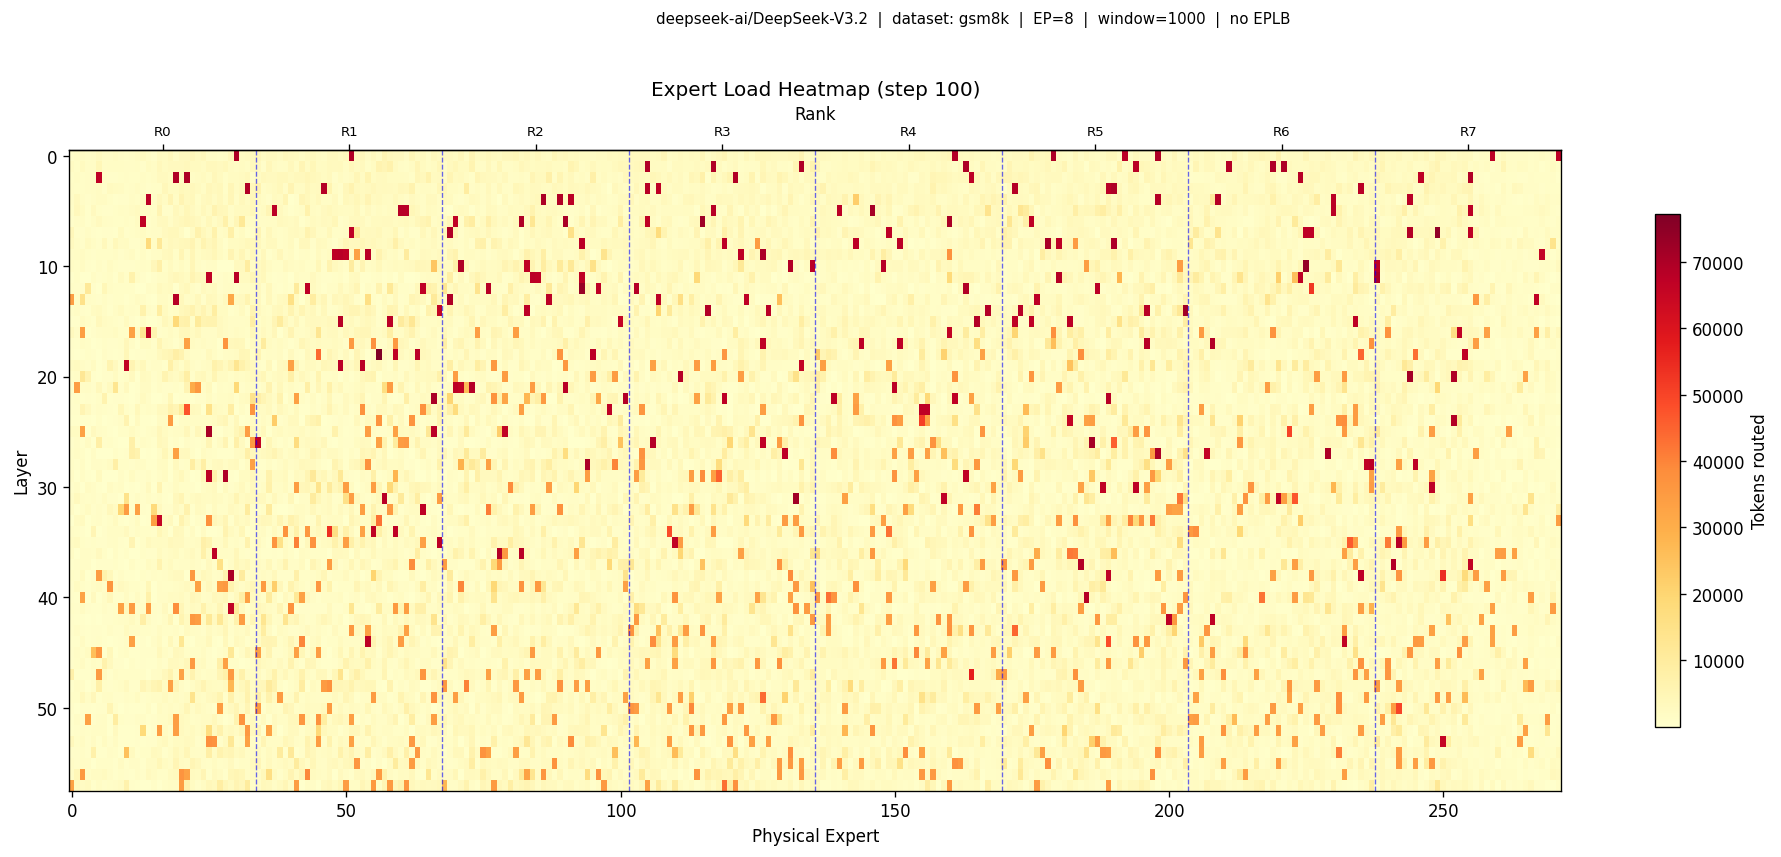

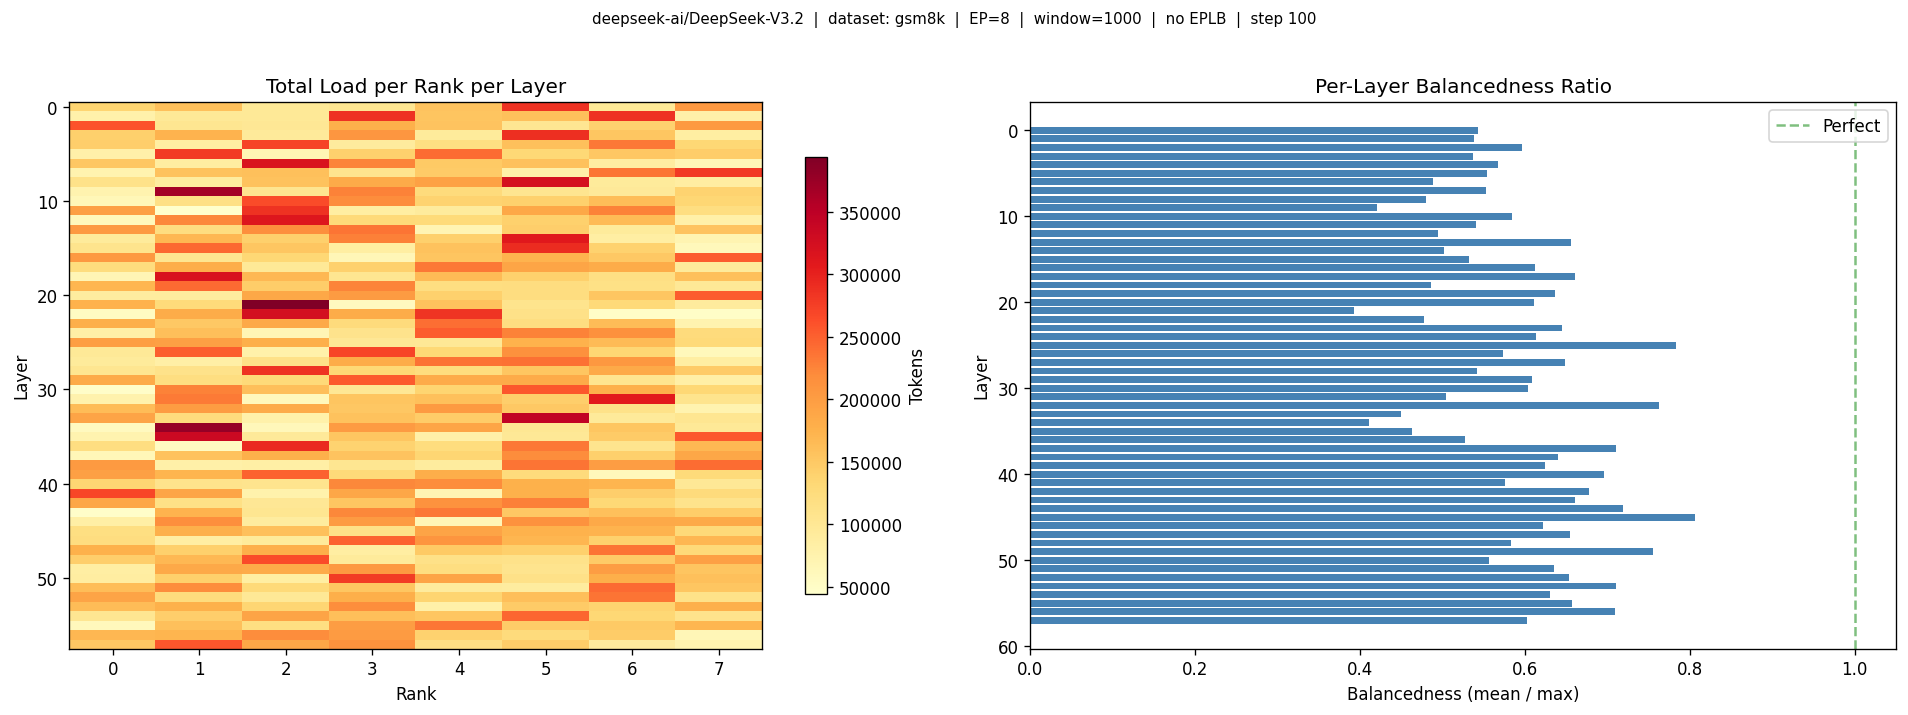

Overall balancedness: 0.5945  (min layer: 0.3926 @ layer 21)


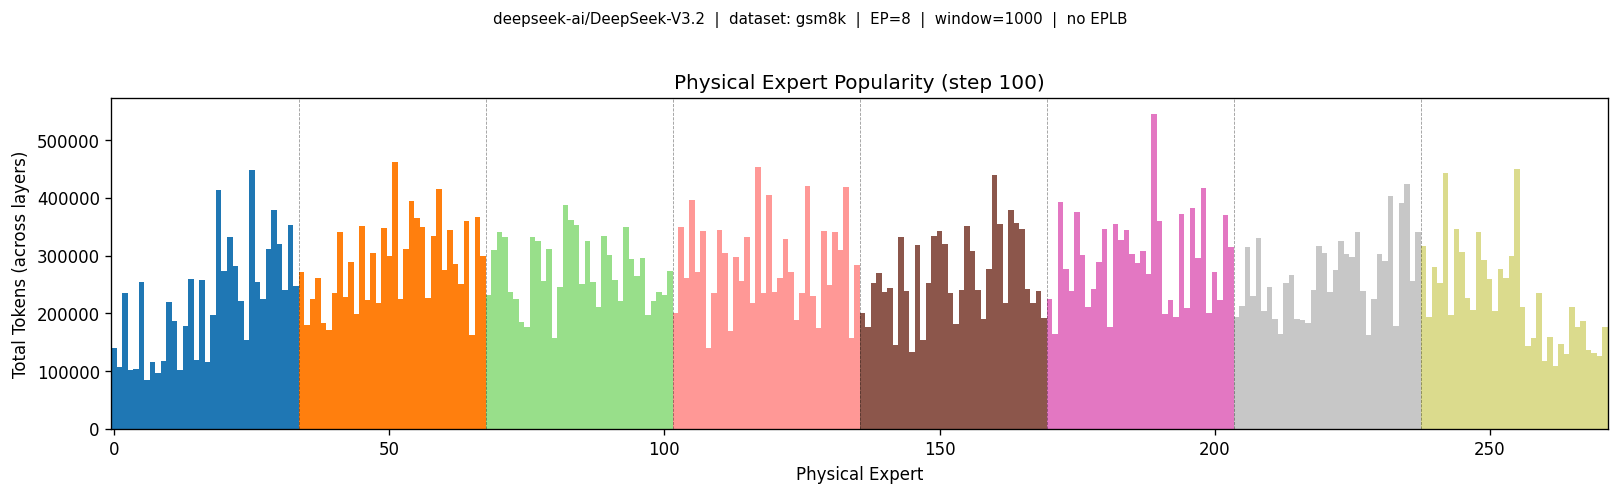

Expert load: mean=264067, std=82194, max/mean=2.07x


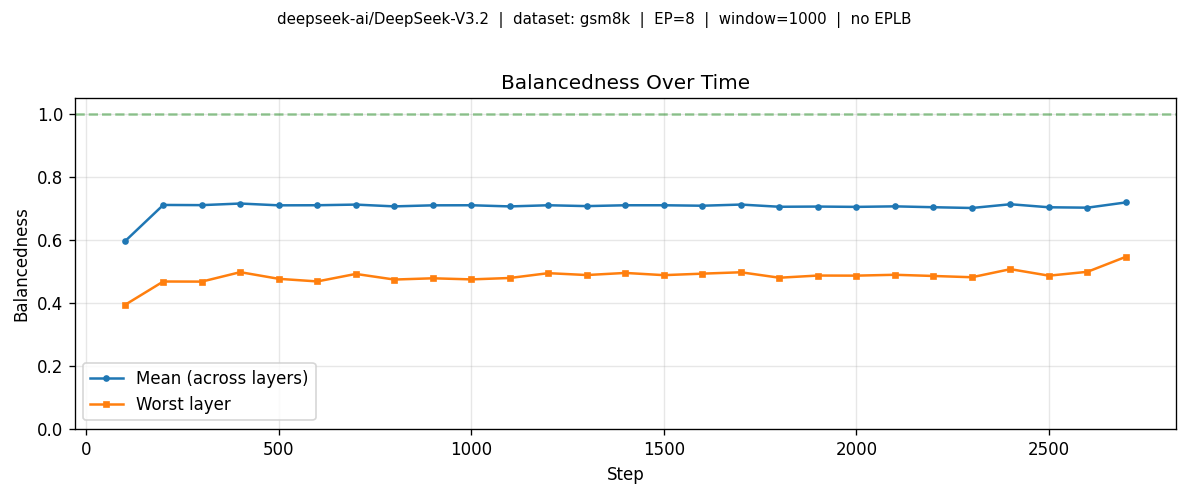

In [ ]:
d_gsm8k = load_eplb_data(
    dataset="gsm8k",
    model="deepseek-ai/DeepSeek-V3.2",
    # world_size=8,  # override to simulate different EP sizes
    tag="no_eplb",
)
# plot_rank_balance(d_gsm8k, snapshot_idx=2)
plot_all(d_gsm8k, snapshot_idx=0)

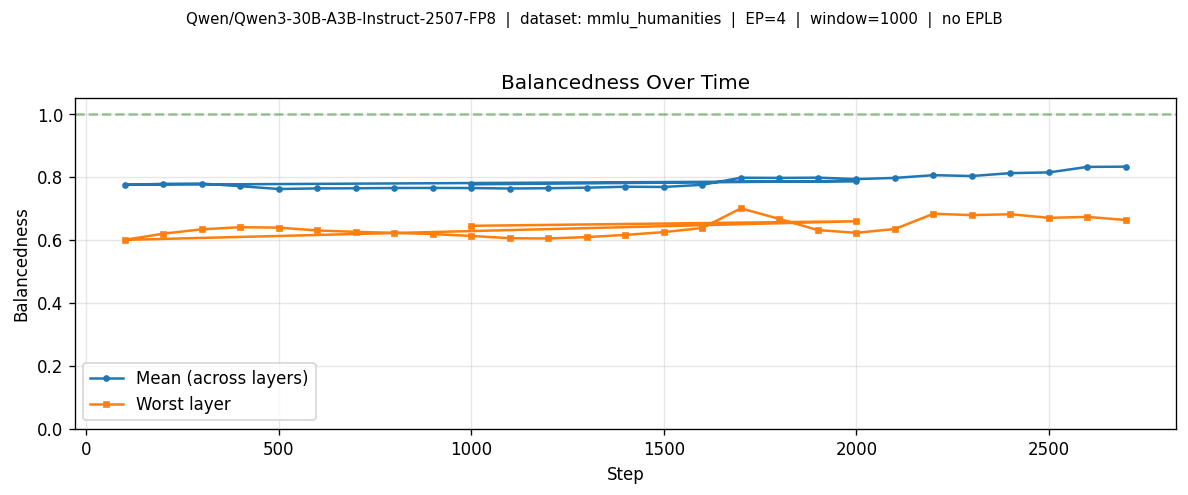

In [77]:
plot_balancedness_over_time(d_mmlu_humanities)